<a href="https://colab.research.google.com/github/DhimanTarafdar/AAA/blob/main/DENV2_Bangladesh_Vaccine_Antigenic_Mismatch_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Setup**

In [ ]:
!pip install biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 19.5 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from Bio import SeqIO, Entrez, Align
from Bio.Seq import Seq
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import GroupKFold, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr, spearmanr, shapiro, wilcoxon, ttest_rel

Entrez.email = "dhimantarafdar23@gmail.com"
CONFIDENCE_LEVEL = 0.95  # 95% CI (alpha = 0.05); change to 0.98 for alpha = 0.02

In [ ]:
sequences = {record.id: str(record.seq) for record in SeqIO.parse("titered_E_aa.mfa", "fasta")}
print("Total sequences in panel:", len(sequences))

wrong_length = {name: len(seq) for name, seq in sequences.items() if len(seq) != 495}
print("Sequences with wrong length:", len(wrong_length))

Total sequences in panel: 48
Sequences with wrong length: 0


In [ ]:
labels = pd.read_csv("elife-42496-fig1-data1-v3.csv")
labels = labels.rename(columns={"titer": "antigenic_distance"})

strain_names = set(sequences.keys())
missing_serum = labels[~labels["serum"].isin(strain_names)]
missing_virus = labels[~labels["virus"].isin(strain_names)]
duplicates = labels[labels.duplicated(subset=["serum", "virus"], keep=False)]
missing_labels = labels[labels["antigenic_distance"].isna()]

print("Unmatched serum:", len(missing_serum))
print("Unmatched virus:", len(missing_virus))
print("Duplicates:", len(duplicates))
print("Missing labels:", len(missing_labels))

Unmatched serum: 0
Unmatched virus: 0
Duplicates: 0
Missing labels: 0


# **Feature Engineering**

In [ ]:
# Charge: physiological pH side-chain charge (H = +1, per IMGT classification)
# Hydrophobicity: Kyte & Doolittle (1982)
# Size: residue volume, Zamyatnin (1972)
amino_acid_properties = {
    'A': {'charge': 0, 'hydrophobicity': 1.8, 'size': 88.6},
    'R': {'charge': 1, 'hydrophobicity': -4.5, 'size': 173.4},
    'N': {'charge': 0, 'hydrophobicity': -3.5, 'size': 114.1},
    'D': {'charge': -1, 'hydrophobicity': -3.5, 'size': 111.1},
    'C': {'charge': 0, 'hydrophobicity': 2.5, 'size': 108.5},
    'Q': {'charge': 0, 'hydrophobicity': -3.5, 'size': 143.8},
    'E': {'charge': -1, 'hydrophobicity': -3.5, 'size': 138.4},
    'G': {'charge': 0, 'hydrophobicity': -0.4, 'size': 60.1},
    'H': {'charge': 1, 'hydrophobicity': -3.2, 'size': 153.2},
    'I': {'charge': 0, 'hydrophobicity': 4.5, 'size': 166.7},
    'L': {'charge': 0, 'hydrophobicity': 3.8, 'size': 166.7},
    'K': {'charge': 1, 'hydrophobicity': -3.9, 'size': 168.6},
    'M': {'charge': 0, 'hydrophobicity': 1.9, 'size': 162.9},
    'F': {'charge': 0, 'hydrophobicity': 2.8, 'size': 189.9},
    'P': {'charge': 0, 'hydrophobicity': -1.6, 'size': 112.7},
    'S': {'charge': 0, 'hydrophobicity': -0.8, 'size': 89.0},
    'T': {'charge': 0, 'hydrophobicity': -0.7, 'size': 116.1},
    'W': {'charge': 0, 'hydrophobicity': -0.9, 'size': 227.8},
    'Y': {'charge': 0, 'hydrophobicity': -1.3, 'size': 193.6},
    'V': {'charge': 0, 'hydrophobicity': 4.2, 'size': 140.0},
}

In [ ]:
def compute_features(seq1, seq2, properties):
    n_sub = 0
    d_charge = 0
    d_hydro = 0
    d_size = 0
    n_skipped = 0

    for aa1, aa2 in zip(seq1, seq2):
        if aa1 == aa2:
            continue
        if aa1 == '-' or aa2 == '-' or aa1 not in properties or aa2 not in properties:
            n_skipped += 1
            continue
        n_sub += 1
        d_charge += abs(properties[aa1]['charge'] - properties[aa2]['charge'])
        d_hydro += abs(properties[aa1]['hydrophobicity'] - properties[aa2]['hydrophobicity'])
        d_size += abs(properties[aa1]['size'] - properties[aa2]['size'])

    return n_sub, d_charge, d_hydro, d_size, n_skipped

In [ ]:
feature_rows = []
for _, row in labels.iterrows():
    n_sub, d_charge, d_hydro, d_size, n_skipped = compute_features(
        sequences[row['serum']], sequences[row['virus']], amino_acid_properties
    )
    feature_rows.append({
        'serum': row['serum'], 'virus': row['virus'],
        'num_substitutions': n_sub, 'total_abs_charge_change': d_charge,
        'total_abs_hydrophobicity_change': d_hydro, 'total_abs_size_change': d_size,
        'skipped_positions': n_skipped, 'antigenic_distance': row['antigenic_distance'],
    })

training_table = pd.DataFrame(feature_rows)
print(training_table.shape)

(540, 8)


# **Model Training, Selection & Validation**

In [ ]:
feature_cols = ['num_substitutions', 'total_abs_charge_change',
                 'total_abs_hydrophobicity_change', 'total_abs_size_change']
X = training_table[feature_cols].values
y = training_table['antigenic_distance'].values
groups = training_table['virus'].values

gkf = GroupKFold(n_splits=5)

In [ ]:
baseline_rmse, baseline_mae = [], []
for train_idx, test_idx in gkf.split(X, y, groups):
    model = DummyRegressor(strategy='mean')
    model.fit(X[train_idx], y[train_idx])
    y_pred = model.predict(X[test_idx])
    baseline_rmse.append(np.sqrt(mean_squared_error(y[test_idx], y_pred)))
    baseline_mae.append(mean_absolute_error(y[test_idx], y_pred))

print("Baseline mean RMSE:", np.mean(baseline_rmse))
print("Baseline mean MAE:", np.mean(baseline_mae))

Baseline mean RMSE: 1.9156009433494616
Baseline mean MAE: 1.439037968157923


In [ ]:
param_grid = {'max_depth': [3, 4, 5, 6], 'min_samples_leaf': [5, 10, 15, 20], 'n_estimators': [300]}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42), param_grid,
    cv=gkf.split(X, y, groups), scoring='neg_root_mean_squared_error', n_jobs=-1
)
grid_search.fit(X, y)
best_params = grid_search.best_params_
print("Best params:", best_params)

Best params: {'max_depth': 3, 'min_samples_leaf': 20, 'n_estimators': 300}


In [ ]:
models_to_test = {
    "RandomForest": RandomForestRegressor(random_state=42, **best_params),
    "Ridge": Ridge(alpha=1.0),
    "GradientBoosting": GradientBoostingRegressor(max_depth=2, min_samples_leaf=20, n_estimators=200, learning_rate=0.05, random_state=42),
    "SVR": SVR(kernel='rbf', C=1.0),
    "GaussianProcess": GaussianProcessRegressor(kernel=RBF() + WhiteKernel(), random_state=42),
}

comparison_results = []
rf_all_actual, rf_all_predicted = [], []
rf_fold_r2, rf_fold_rmse = [], []  # kept separately to build a bootstrap CI below

for model_name, model in models_to_test.items():
    fold_rmse, fold_r2, fold_mae, fold_spearman = [], [], [], []

    for train_idx, test_idx in gkf.split(X, y, groups):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        if model_name in ["SVR", "GaussianProcess"]:
            scaler = StandardScaler()
            X_train, X_test = scaler.fit_transform(X_train), scaler.transform(X_test)

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        fold_rmse.append(np.sqrt(mean_squared_error(y_test, y_pred)))
        fold_r2.append(r2_score(y_test, y_pred))
        fold_mae.append(mean_absolute_error(y_test, y_pred))
        fold_spearman.append(spearmanr(y_test, y_pred)[0])

        if model_name == "RandomForest":
            rf_all_actual.extend(y_test)
            rf_all_predicted.extend(y_pred)

    if model_name == "RandomForest":
        rf_fold_r2, rf_fold_rmse = fold_r2, fold_rmse

    comparison_results.append({
        'model': model_name, 'mean_rmse': np.mean(fold_rmse), 'mean_r2': np.mean(fold_r2),
        'mean_mae': np.mean(fold_mae), 'mean_spearman': np.mean(fold_spearman), 'std_r2': np.std(fold_r2),
    })

comparison_table = pd.DataFrame(comparison_results).sort_values('mean_r2', ascending=False)
print(comparison_table)

              model  mean_rmse   mean_r2  mean_mae  mean_spearman    std_r2
4   GaussianProcess   1.721788  0.183227  1.301553       0.456378  0.078939
0      RandomForest   1.741412  0.166674  1.300019       0.446890  0.075349
1             Ridge   1.759931  0.148089  1.355484       0.381292  0.040187
3               SVR   1.761503  0.146638  1.258954       0.461539  0.052812
2  GradientBoosting   1.772138  0.133896  1.315171       0.453033  0.122321


In [ ]:
# Bootstrap confidence interval for the Random Forest's CV performance (R2 and RMSE)
# We resample the 5 fold-level scores with replacement many times and take percentiles
def bootstrap_ci(values, confidence_level, n_bootstrap=10000, random_state=42):
    rng = np.random.default_rng(random_state)
    values = np.array(values)
    boot_means = [rng.choice(values, size=len(values), replace=True).mean() for _ in range(n_bootstrap)]
    alpha = 1 - confidence_level
    lower = np.percentile(boot_means, 100 * (alpha / 2))
    upper = np.percentile(boot_means, 100 * (1 - alpha / 2))
    return np.mean(values), lower, upper

r2_mean, r2_lower, r2_upper = bootstrap_ci(rf_fold_r2, CONFIDENCE_LEVEL)
rmse_mean, rmse_lower, rmse_upper = bootstrap_ci(rf_fold_rmse, CONFIDENCE_LEVEL)

print(f"R2:   {r2_mean:.3f}  ({int(CONFIDENCE_LEVEL*100)}% CI: {r2_lower:.3f} to {r2_upper:.3f})")
print(f"RMSE: {rmse_mean:.3f}  ({int(CONFIDENCE_LEVEL*100)}% CI: {rmse_lower:.3f} to {rmse_upper:.3f})")

R2:   0.167  (95% CI: 0.098 to 0.229)
RMSE: 1.741  (95% CI: 1.634 to 1.871)


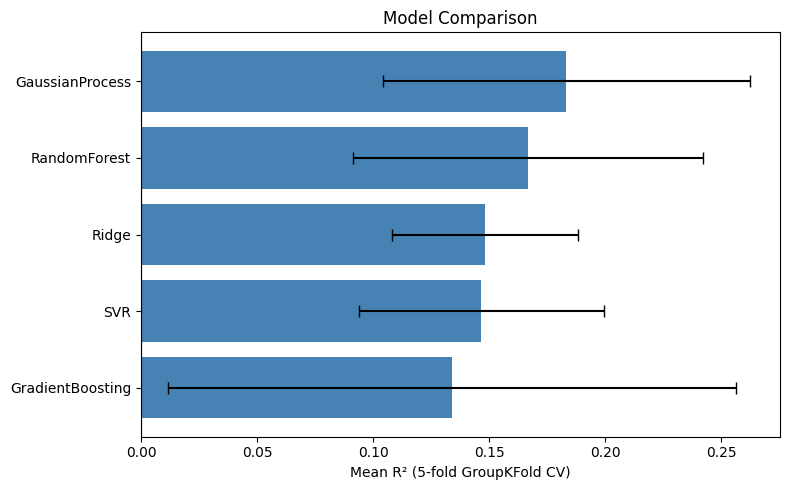

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
sorted_table = comparison_table.sort_values('mean_r2', ascending=True)
ax.barh(sorted_table['model'], sorted_table['mean_r2'], xerr=sorted_table['std_r2'], color='steelblue', capsize=4)
ax.set_xlabel('Mean R² (5-fold GroupKFold CV)')
ax.set_title('Model Comparison')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

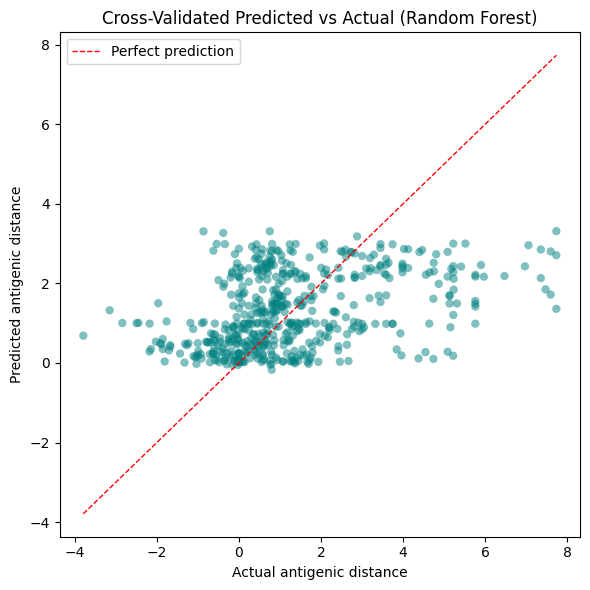

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(rf_all_actual, rf_all_predicted, alpha=0.5, color='teal', edgecolor='none')
lims = [min(rf_all_actual + rf_all_predicted), max(rf_all_actual + rf_all_predicted)]
ax.plot(lims, lims, 'r--', linewidth=1, label='Perfect prediction')
ax.set_xlabel('Actual antigenic distance')
ax.set_ylabel('Predicted antigenic distance')
ax.set_title('Cross-Validated Predicted vs Actual (Random Forest)')
ax.legend()
plt.tight_layout()
plt.savefig('predicted_vs_actual.png', dpi=150)
plt.show()

In [ ]:
final_model = RandomForestRegressor(random_state=42, **best_params)
final_model.fit(X, y)

importance_table = pd.DataFrame({
    'feature': feature_cols, 'importance': final_model.feature_importances_
}).sort_values('importance', ascending=False)
print(importance_table)

                           feature  importance
1          total_abs_charge_change    0.482175
2  total_abs_hydrophobicity_change    0.383318
3            total_abs_size_change    0.104065
0                num_substitutions    0.030443


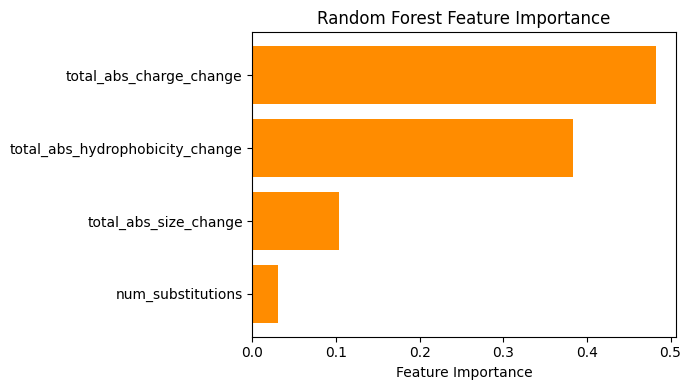

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
sorted_importance = importance_table.sort_values('importance', ascending=True)
ax.barh(sorted_importance['feature'], sorted_importance['importance'], color='darkorange')
ax.set_xlabel('Feature Importance')
ax.set_title('Random Forest Feature Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

# **Apply to Bangladeshi DENV2 Strains**

In [ ]:
vaccine_accessions = {
    "CYD-TDV_DENV1": "KX239894", "CYD-TDV_DENV2": "KX239895",
    "CYD-TDV_DENV3": "KX239896", "CYD-TDV_DENV4": "KX239897",
    "TV003_DENV1": "U88535", "TV003_DENV2": "KM204118",
    "TV003_DENV3": "AY648961", "TV003_DENV4": "AF326825",
    "TAK003_DENV1": "AF180817", "TAK003_DENV2": "KU725664",
    "TAK003_DENV3": "KU725665", "TAK003_DENV4": "U18429",
}

def get_envelope_protein(accession):
    handle = Entrez.efetch(db="nucleotide", id=accession, rettype="gb", retmode="text")
    record = SeqIO.read(handle, "genbank")
    handle.close()
    for feature in record.features:
        if feature.type not in ("CDS", "mat_peptide"):
            continue
        product = " ".join(feature.qualifiers.get("product", [""])).lower().strip()
        if "envelope" in product or product == "e":
            translation = feature.qualifiers.get("translation")
            if translation:
                return translation[0]
            return str(feature.extract(record.seq).translate(to_stop=True))
    return None

def extract_e_by_alignment(accession, reference_e_protein):
    handle = Entrez.efetch(db="nucleotide", id=accession, rettype="gb", retmode="text")
    record = SeqIO.read(handle, "genbank")
    handle.close()

    cds_feature = next(f for f in record.features if f.type == "CDS")
    translation = cds_feature.qualifiers.get("translation")
    polyprotein_seq = translation[0] if translation else str(cds_feature.extract(record.seq).translate(to_stop=True))

    aligner = Align.PairwiseAligner()
    aligner.mode = "local"
    aligner.open_gap_score = -10
    aligner.extend_gap_score = -0.5
    aligner.match_score = 2
    aligner.mismatch_score = -1

    alignment = aligner.align(polyprotein_seq, reference_e_protein)[0]
    start, end = alignment.aligned[0][0][0], alignment.aligned[0][-1][1]
    return polyprotein_seq[start:end]

In [ ]:
vaccine_e_proteins = {}
for label, accession in vaccine_accessions.items():
    vaccine_e_proteins[label] = get_envelope_protein(accession)

vaccine_e_proteins["TAK003_DENV2"] = extract_e_by_alignment("KU725664", vaccine_e_proteins["TV003_DENV2"])
vaccine_e_proteins["TAK003_DENV3"] = extract_e_by_alignment("KU725665", vaccine_e_proteins["TV003_DENV3"])

for label, protein in vaccine_e_proteins.items():
    print(label, len(protein) if protein else "MISSING")

CYD-TDV_DENV1 495
CYD-TDV_DENV2 495
CYD-TDV_DENV3 493
CYD-TDV_DENV4 495
TV003_DENV1 497
TV003_DENV2 495
TV003_DENV3 493
TV003_DENV4 495
TAK003_DENV1 495
TAK003_DENV2 495
TAK003_DENV3 493
TAK003_DENV4 495


In [ ]:
def get_six_frame_translations(nt_seq):
    frames = []
    seq = Seq(nt_seq)
    rev_seq = seq.reverse_complement()
    for frame in range(3):
        trimmed = seq[frame:]
        trimmed = trimmed[:len(trimmed) - len(trimmed) % 3]
        frames.append(str(trimmed.translate(to_stop=False)))
    for frame in range(3):
        trimmed = rev_seq[frame:]
        trimmed = trimmed[:len(trimmed) - len(trimmed) % 3]
        frames.append(str(trimmed.translate(to_stop=False)))
    return frames

def extract_e_protein_bd(nt_seq, reference_e_protein, min_score=400):
    aligner = Align.PairwiseAligner()
    aligner.mode = "local"
    aligner.open_gap_score = -10
    aligner.extend_gap_score = -0.5
    aligner.match_score = 2
    aligner.mismatch_score = -1

    best_score, best_segment = -1, None
    for frame_seq in get_six_frame_translations(nt_seq):
        if len(frame_seq) < 50:
            continue
        alignment = aligner.align(frame_seq, reference_e_protein)[0]
        if alignment.score > best_score:
            start, end = alignment.aligned[0][0][0], alignment.aligned[0][-1][1]
            best_score = alignment.score
            best_segment = frame_seq[start:end]

    if best_score < min_score:
        return None
    return best_segment

In [ ]:
denv2_bd_sequences = {record.id: str(record.seq) for record in SeqIO.parse("DENV2_Bangladesh.fasta", "fasta")}
denv2_reference = vaccine_e_proteins["TV003_DENV2"]

bd_e_proteins = {}
for name, nt_seq in denv2_bd_sequences.items():
    protein = extract_e_protein_bd(nt_seq, denv2_reference)
    if protein is not None and len(protein) == 495:
        bd_e_proteins[name] = protein

print("BD strains with full E-protein coverage:", len(bd_e_proteins))

BD strains with full E-protein coverage: 141


In [ ]:
combined_records = []
for name, seq in bd_e_proteins.items():
    combined_records.append(f">BD_{name}\n{seq}")
for name, seq in sequences.items():
    combined_records.append(f">PANEL_{name}\n{seq}")
for name, seq in vaccine_e_proteins.items():
    combined_records.append(f">VACCINE_{name}\n{seq}")

with open("combined_for_alignment.fasta", "w") as f:
    f.write("\n".join(combined_records))

!apt-get -qq install -y muscle
!muscle -align combined_for_alignment.fasta -output combined_aligned.fasta

Selecting previously unselected package muscle.
(Reading database ... 122809 files and directories currently installed.)
Preparing to unpack .../muscle_1%3a5.1.0-1_amd64.deb ...
Unpacking muscle (1:5.1.0-1) ...
Setting up muscle (1:5.1.0-1) ...
Processing triggers for man-db (2.12.0-4build2) ...

muscle 5.2.linux64 [-]  13.3Gb RAM, 2 cores
Built Nov  5 2022 18:45:38
(C) Copyright 2004-2021 Robert C. Edgar.
https://drive5.com

Input: 201 seqs, avg length 495, max 497

00:00 11Mb   CPU has 2 cores, running 2 threads
10:51 240Mb   100.0% Calc posteriors
11:15 396Mb   100.0% Consistency (1/2)
11:38 396Mb   100.0% Consistency (2/2)
11:38 396Mb   100.0% UPGMA5
11:43 407Mb   100.0% Refining


In [ ]:
aligned_records = {record.id: str(record.seq) for record in SeqIO.parse("combined_aligned.fasta", "fasta")}

bd_aligned = {name.replace("BD_", ""): seq for name, seq in aligned_records.items() if name.startswith("BD_")}
panel_aligned = {name.replace("PANEL_", ""): seq for name, seq in aligned_records.items() if name.startswith("PANEL_")}
vaccine_aligned = {name.replace("VACCINE_", ""): seq for name, seq in aligned_records.items() if name.startswith("VACCINE_")}

print("BD:", len(bd_aligned), "Panel:", len(panel_aligned), "Vaccine:", len(vaccine_aligned))

BD: 141 Panel: 48 Vaccine: 12


In [ ]:
vaccine_tier_map = {
    "TV003_DENV2":  {"tier": "validated",    "ref_seq": panel_aligned["DENV2/TONGA/DELTA30/1974"]},
    "TAK003_DENV2": {"tier": "extrapolated", "ref_seq": vaccine_aligned["TAK003_DENV2"]},
    "CYDTDV_DENV2": {"tier": "extrapolated", "ref_seq": vaccine_aligned["CYD-TDV_DENV2"]},
}

results = []
for bd_name, bd_seq in bd_aligned.items():
    for vaccine_label, info in vaccine_tier_map.items():
        n_sub, d_charge, d_hydro, d_size, n_skipped = compute_features(bd_seq, info["ref_seq"], amino_acid_properties)
        prediction = final_model.predict([[n_sub, d_charge, d_hydro, d_size]])[0]
        results.append({
            'bd_strain': bd_name, 'vaccine': vaccine_label,
            'num_substitutions': n_sub, 'total_abs_charge_change': d_charge,
            'total_abs_hydrophobicity_change': d_hydro, 'total_abs_size_change': d_size,
            'skipped_positions': n_skipped, 'predicted_mismatch_score': prediction,
            'confidence_tier': info["tier"]
        })

mismatch_table_final = pd.DataFrame(results)
mismatch_table_final.to_csv("denv2_vaccine_mismatch_predictions.csv", index=False)

summary_final = mismatch_table_final.groupby('vaccine')['predicted_mismatch_score'].agg(['mean', 'std', 'count'])
print(summary_final)

                  mean       std  count
vaccine                                
CYDTDV_DENV2  0.732897  0.437976    141
TAK003_DENV2  0.275401  0.357945    141
TV003_DENV2   0.333149  0.307165    141


/tmp/ipykernel_1008/1486696865.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_by_vaccine, labels=vaccines_order, patch_artist=True, boxprops=dict(facecolor='lightblue'))


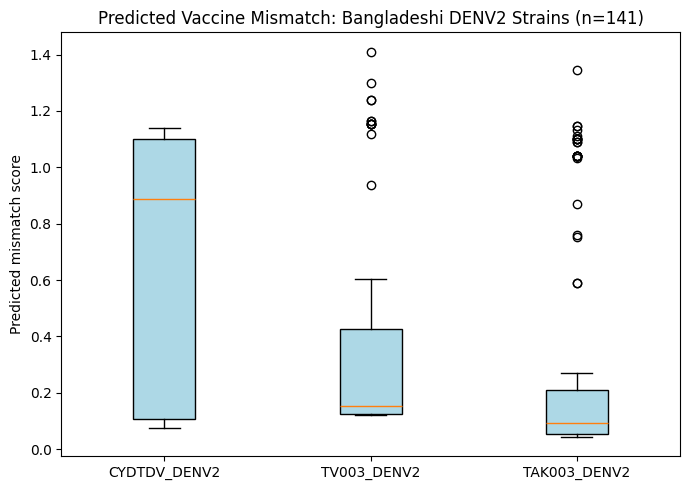

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
vaccines_order = ['CYDTDV_DENV2', 'TV003_DENV2', 'TAK003_DENV2']
data_by_vaccine = [mismatch_table_final[mismatch_table_final['vaccine'] == v]['predicted_mismatch_score'] for v in vaccines_order]

ax.boxplot(data_by_vaccine, labels=vaccines_order, patch_artist=True, boxprops=dict(facecolor='lightblue'))
ax.set_ylabel('Predicted mismatch score')
ax.set_title(f'Predicted Vaccine Mismatch: Bangladeshi DENV2 Strains (n={len(bd_aligned)})')
plt.tight_layout()
plt.savefig('bd_mismatch_by_vaccine.png', dpi=150)
plt.show()

# **Statistical Testing: Is the vaccine mismatch difference significant?**

In [ ]:
# Reshape into wide format: one row per BD strain, one column per vaccine
# This is required because the comparison is paired (same strain, 3 vaccines)
wide_table = mismatch_table_final.pivot(index='bd_strain', columns='vaccine', values='predicted_mismatch_score')
print(wide_table.head())

vaccine     CYDTDV_DENV2  TAK003_DENV2  TV003_DENV2
bd_strain                                          
EU448423.1      1.106746      1.098913     1.155415
EU448424.1      1.065990      0.871132     1.118606
JN036372.1      1.091387      1.112051     0.936179
JN036373.1      1.106746      1.098913     1.155415
JN036374.1      0.108682      0.114826     0.401604


In [ ]:
# Step 1: test normality of each vaccine's score distribution (Shapiro-Wilk)
# This decides whether a parametric (t-test) or non-parametric (Wilcoxon) test is appropriate
print("Shapiro-Wilk normality test (p < 0.05 means NOT normally distributed):")
for vaccine in vaccines_order:
    stat, p_value = shapiro(wide_table[vaccine])
    print(f"{vaccine}: W={stat:.3f}, p={p_value:.4f}, {'NOT normal' if p_value < 0.05 else 'normal'}")

Shapiro-Wilk normality test (p < 0.05 means NOT normally distributed):
CYDTDV_DENV2: W=0.701, p=0.0000, NOT normal
TV003_DENV2: W=0.665, p=0.0000, NOT normal
TAK003_DENV2: W=0.613, p=0.0000, NOT normal


In [ ]:
# Step 2: pairwise comparison between the 3 vaccines
# Both tests are computed - the normality result above decides which one to report as primary
pairs = [('CYDTDV_DENV2', 'TV003_DENV2'), ('CYDTDV_DENV2', 'TAK003_DENV2'), ('TV003_DENV2', 'TAK003_DENV2')]

test_results = []
for vaccine_a, vaccine_b in pairs:
    values_a = wide_table[vaccine_a]
    values_b = wide_table[vaccine_b]

    wilcoxon_stat, wilcoxon_p = wilcoxon(values_a, values_b)
    ttest_stat, ttest_p = ttest_rel(values_a, values_b)

    test_results.append({
        'comparison': f"{vaccine_a} vs {vaccine_b}",
        'wilcoxon_p_value': wilcoxon_p,
        'paired_ttest_p_value': ttest_p,
        'significant_at_0.05': wilcoxon_p < 0.05
    })

test_results_table = pd.DataFrame(test_results)
print(test_results_table)

                     comparison  wilcoxon_p_value  paired_ttest_p_value  \
0   CYDTDV_DENV2 vs TV003_DENV2      1.893527e-11          9.992555e-14   
1  CYDTDV_DENV2 vs TAK003_DENV2      4.026327e-22          1.191921e-23   
2   TV003_DENV2 vs TAK003_DENV2      1.645950e-03          2.236937e-02   

   significant_at_0.05  
0                 True  
1                 True  
2                 True  


In [ ]:
# Step 3: bootstrap confidence interval for each vaccine's mean mismatch score
print(f"{int(CONFIDENCE_LEVEL*100)}% Confidence Intervals (bootstrap):\n")
for vaccine in vaccines_order:
    mean_val, lower, upper = bootstrap_ci(wide_table[vaccine].values, CONFIDENCE_LEVEL)
    print(f"{vaccine}: mean={mean_val:.3f}, CI=({lower:.3f}, {upper:.3f})")

95% Confidence Intervals (bootstrap):

CYDTDV_DENV2: mean=0.733, CI=(0.662, 0.804)
TV003_DENV2: mean=0.333, CI=(0.285, 0.384)
TAK003_DENV2: mean=0.275, CI=(0.219, 0.337)


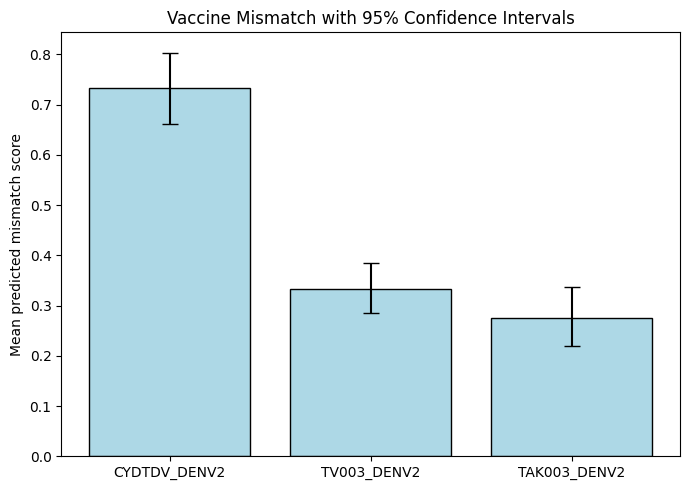

In [ ]:
# Graph: mean mismatch score per vaccine with confidence interval error bars
fig, ax = plt.subplots(figsize=(7, 5))
means, lowers, uppers = [], [], []

for vaccine in vaccines_order:
    mean_val, lower, upper = bootstrap_ci(wide_table[vaccine].values, CONFIDENCE_LEVEL)
    means.append(mean_val)
    lowers.append(mean_val - lower)
    uppers.append(upper - mean_val)

ax.bar(vaccines_order, means, yerr=[lowers, uppers], capsize=6, color='lightblue', edgecolor='black')
ax.set_ylabel('Mean predicted mismatch score')
ax.set_title(f'Vaccine Mismatch with {int(CONFIDENCE_LEVEL*100)}% Confidence Intervals')
plt.tight_layout()
plt.savefig('vaccine_mismatch_with_ci.png', dpi=150)
plt.show()

In [ ]:
# Bonferroni-corrected significance check
alpha = 0.05
n_comparisons = len(pairs)
bonferroni_alpha = alpha / n_comparisons

test_results_table['significant_after_bonferroni'] = test_results_table['wilcoxon_p_value'] < bonferroni_alpha
print(f"Bonferroni-corrected alpha: {bonferroni_alpha:.4f}")
test_results_table

Bonferroni-corrected alpha: 0.0167


,comparison,wilcoxon_p_value,paired_ttest_p_value,significant_at_0.05,significant_after_bonferroni
0,CYDTDV_DENV2 vs TV003_DENV2,1.893527e-11,9.992555e-14,True,True
1,CYDTDV_DENV2 vs TAK003_DENV2,4.026327e-22,1.191921e-23,True,True
2,TV003_DENV2 vs TAK003_DENV2,1.645950e-03,2.236937e-02,True,True
